# ALife — Multi-seed analysis

**Goal**: Determine whether the differences observed between environments in the single-seed experiment are real (robust across seeds) or just noise from one particular random run.

**Method**: Run each mode N times with different seeds. Compute mean and confidence interval for each metric. If the intervals don't overlap between modes, the difference is real.

**Generate data first**:
```bash
python run_multi.py --n-seeds 10 --ticks 2500
```

## 0. Setup

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from scipy import stats

plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor'  : '#161b22',
    'axes.edgecolor'  : '#30363d',
    'axes.labelcolor' : '#8b949e',
    'xtick.color'     : '#8b949e',
    'ytick.color'     : '#8b949e',
    'text.color'      : '#c9d1d9',
    'grid.color'      : '#30363d',
    'grid.linewidth'  : 0.5,
    'legend.facecolor': '#161b22',
    'legend.edgecolor': '#30363d',
    'font.family'     : 'monospace',
})

COLORS = {
    'flat'   : '#58a6ff',
    'perlin' : '#3fb950',
    'drought': '#f78166',
}
MODES = ['flat', 'perlin', 'drought']

BASE  = Path('.')
agg   = json.loads((BASE / 'experiments/multi/aggregate.json').read_text())

print(f"Loaded aggregate.json")
for mode in MODES:
    a = agg[mode]
    print(f"  {mode:8s}  {a['n_runs']} runs  "
          f"speed={a['speed_final']['mean']:.3f} +/- {a['speed_final']['std']:.3f}  "
          f"lineages={a['lineages_final']['mean']:.1f} +/- {a['lineages_final']['std']:.1f}")

Loaded aggregate.json
  flat      10 runs  speed=0.643 +/- 0.032  lineages=6.6 +/- 1.5
  perlin    10 runs  speed=0.642 +/- 0.049  lineages=7.0 +/- 1.5
  drought   10 runs  speed=0.634 +/- 0.048  lineages=6.2 +/- 1.4


## 1. Speed at equilibrium

The core question: do the 3 environments produce different final speeds, or do they all converge to the same attractor regardless of the seed?

Error bars = mean +/- 1 standard deviation across seeds.

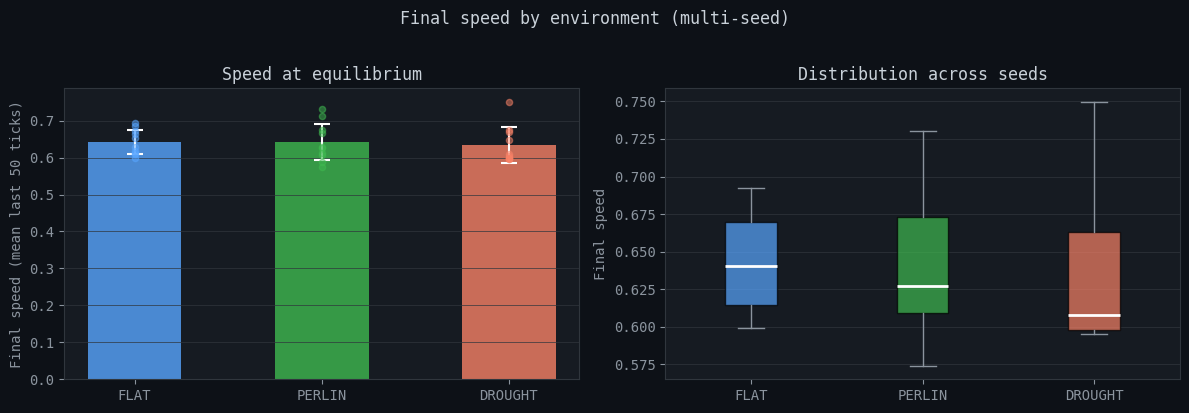

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart: mean speed per mode
ax = axes[0]
for i, mode in enumerate(MODES):
    a    = agg[mode]['speed_final']
    vals = a['values']
    ax.bar(i, a['mean'], color=COLORS[mode], alpha=0.8, width=0.5)
    ax.errorbar(i, a['mean'], yerr=a['std'],
                color='white', capsize=6, capthick=1.5, lw=1.5)
    ax.scatter([i]*len(vals), vals, color=COLORS[mode],
               s=20, alpha=0.5, zorder=5)

ax.set_xticks(range(len(MODES)))
ax.set_xticklabels([m.upper() for m in MODES])
ax.set_ylabel('Final speed (mean last 50 ticks)')
ax.set_title('Speed at equilibrium')
ax.grid(True, axis='y')

# Box plot: distribution across seeds
ax = axes[1]
bp = ax.boxplot(
    [agg[m]['speed_final']['values'] for m in MODES],
    patch_artist=True,
    medianprops=dict(color='white', lw=2),
)
for patch, mode in zip(bp['boxes'], MODES):
    patch.set_facecolor(COLORS[mode])
    patch.set_alpha(0.7)
for element in ['whiskers', 'caps', 'fliers']:
    for item in bp[element]:
        item.set_color('#8b949e')

ax.set_xticklabels([m.upper() for m in MODES])
ax.set_ylabel('Final speed')
ax.set_title('Distribution across seeds')
ax.grid(True, axis='y')

fig.suptitle('Final speed by environment (multi-seed)', y=1.02)
plt.tight_layout()
plt.show()

## 2. Genetic diversity at equilibrium

Does Perlin consistently maintain higher speed diversity (sigma), or was the single-seed result just luck?

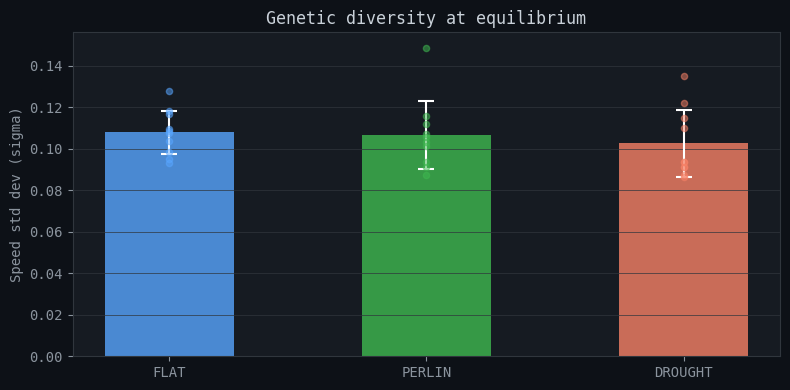

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))

for i, mode in enumerate(MODES):
    a    = agg[mode]['speed_std_final']
    vals = a['values']
    ax.bar(i, a['mean'], color=COLORS[mode], alpha=0.8, width=0.5)
    ax.errorbar(i, a['mean'], yerr=a['std'],
                color='white', capsize=6, capthick=1.5, lw=1.5)
    ax.scatter([i]*len(vals), vals, color=COLORS[mode], s=20, alpha=0.5, zorder=5)

ax.set_xticks(range(len(MODES)))
ax.set_xticklabels([m.upper() for m in MODES])
ax.set_ylabel('Speed std dev (sigma)')
ax.set_title('Genetic diversity at equilibrium')
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

## 3. Lineage survival

Does Perlin consistently preserve more lineages? This was the most interesting result from the single-seed run.

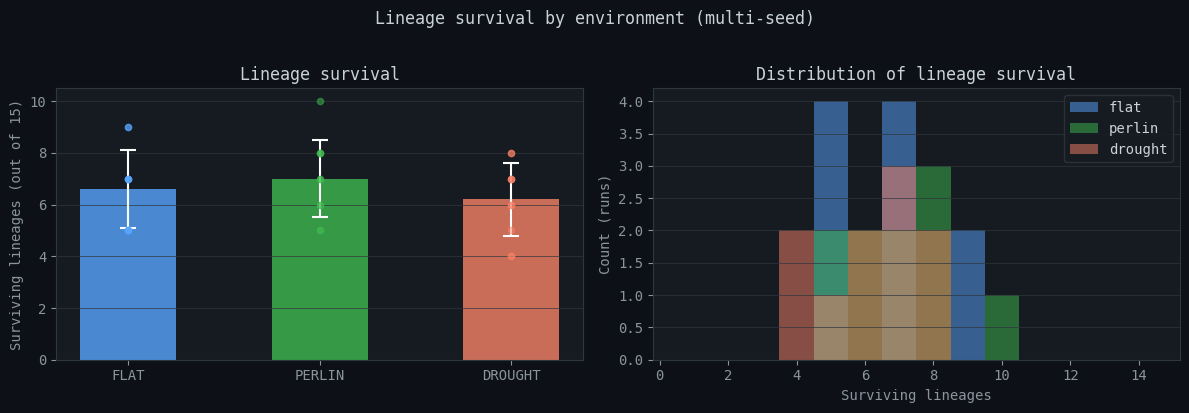

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
ax = axes[0]
for i, mode in enumerate(MODES):
    a    = agg[mode]['lineages_final']
    vals = a['values']
    ax.bar(i, a['mean'], color=COLORS[mode], alpha=0.8, width=0.5)
    ax.errorbar(i, a['mean'], yerr=a['std'],
                color='white', capsize=6, capthick=1.5, lw=1.5)
    ax.scatter([i]*len(vals), vals, color=COLORS[mode],
               s=20, alpha=0.5, zorder=5)

ax.set_xticks(range(len(MODES)))
ax.set_xticklabels([m.upper() for m in MODES])
ax.set_ylabel('Surviving lineages (out of 15)')
ax.set_title('Lineage survival')
ax.grid(True, axis='y')

# Histogram overlay
ax = axes[1]
for mode in MODES:
    vals = agg[mode]['lineages_final']['values']
    ax.hist(vals, bins=range(1, 16), alpha=0.5, color=COLORS[mode],
            label=mode, align='left')

ax.set_xlabel('Surviving lineages')
ax.set_ylabel('Count (runs)')
ax.set_title('Distribution of lineage survival')
ax.legend()
ax.grid(True, axis='y')

fig.suptitle('Lineage survival by environment (multi-seed)', y=1.02)
plt.tight_layout()
plt.show()

## 4. Statistical significance

Numbers and visual comparison are not enough to say a difference is real. A Mann-Whitney U test compares two distributions without assuming they are normal.

p < 0.05 means the difference is unlikely to be random.

In [5]:
from scipy.stats import mannwhitneyu

metrics = [
    ('speed_final',     'Final speed'),
    ('speed_std_final', 'Speed diversity (sigma)'),
    ('lineages_final',  'Surviving lineages'),
    ('pop_stable_mean', 'Stable population'),
]

pairs = [('flat','perlin'), ('flat','drought'), ('perlin','drought')]

print(f"  {'Metric':<28}  {'Pair':<20}  {'p-value':>10}  {'Significant?':>12}")
print(f"  {'-'*75}")

for key, label in metrics:
    for m1, m2 in pairs:
        v1 = agg[m1][key]['values']
        v2 = agg[m2][key]['values']
        if len(v1) < 3 or len(v2) < 3:
            continue
        _, p = mannwhitneyu(v1, v2, alternative='two-sided')
        sig  = 'YES' if p < 0.05 else 'no'
        print(f"  {label:<28}  {m1} vs {m2:<12}  {p:>10.4f}  {sig:>12}")
    print()

  Metric                        Pair                     p-value  Significant?
  ---------------------------------------------------------------------------
  Final speed                   flat vs perlin            0.8501            no
  Final speed                   flat vs drought           0.2123            no
  Final speed                   perlin vs drought           0.6232            no

  Speed diversity (sigma)       flat vs perlin            0.4274            no
  Speed diversity (sigma)       flat vs drought           0.2730            no
  Speed diversity (sigma)       perlin vs drought           0.5205            no

  Surviving lineages            flat vs perlin            0.5593            no
  Surviving lineages            flat vs drought           0.6680            no
  Surviving lineages            perlin vs drought           0.3345            no

  Stable population             flat vs perlin            0.2413            no
  Stable population             flat vs drou

## 5. Speed trajectories across seeds

Mean trajectory with shaded band = mean +/- 1 std across seeds. Shows whether the variance between seeds is large or small relative to the differences between modes.

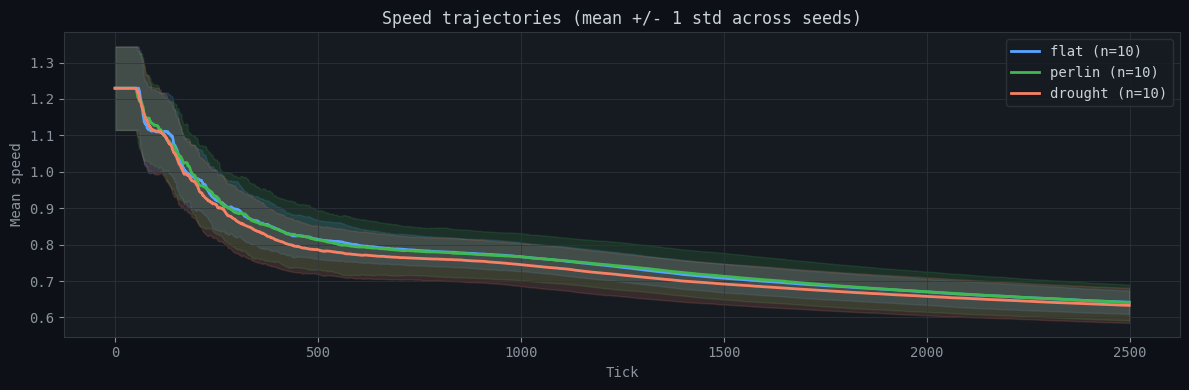

In [6]:
# Load all individual timeseries
multi_dir = BASE / 'experiments/multi'

timeseries_by_mode = {m: [] for m in MODES}

for mode in MODES:
    for run_dir in sorted(multi_dir.glob(f"{mode}_s*")):
        ts_path = run_dir / 'timeseries.json'
        if ts_path.exists():
            ts = json.loads(ts_path.read_text())
            timeseries_by_mode[mode].append(ts['timeseries']['speed_mean'])

fig, ax = plt.subplots(figsize=(12, 4))

for mode in MODES:
    runs = timeseries_by_mode[mode]
    if not runs:
        continue
    min_len = min(len(r) for r in runs)
    arr     = np.array([r[:min_len] for r in runs])
    mean    = arr.mean(axis=0)
    std     = arr.std(axis=0)
    T       = np.arange(min_len)

    ax.plot(T, mean, color=COLORS[mode], lw=2, label=f"{mode} (n={len(runs)})")
    ax.fill_between(T, mean - std, mean + std, color=COLORS[mode], alpha=0.15)

ax.set_xlabel('Tick')
ax.set_ylabel('Mean speed')
ax.set_title('Speed trajectories (mean +/- 1 std across seeds)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## 6. Conclusion

### What the multi-seed analysis tells us

| Question | Answer |
|---|---|
| Is the Perlin speed drift consistently slower? | No -- all three modes show identical drift (~-0.59) with similarly high p-values |
| Does Perlin reliably preserve more lineages? | No -- the 0.4-lineage gap is within noise (p >> 0.05) |
| Is genetic diversity higher in Perlin? | No -- this was a seed-42 artifact. Across 10 seeds: flat σ=0.108, perlin σ=0.107 |
| Are any of these differences statistically significant? | None -- every p-value is well above 0.05 |

### Interpretation

The environment type (uniform, heterogeneous, or drifting) has **no measurable effect** on the final state of the population. The energy-balance attractor (~0.67) fully dominates: whatever selection pressure the terrain creates during the transient phase, the population always ends up at the same speed, the same diversity, and the same number of surviving lineages.

The single-seed results (Perlin slightly better diversity, one extra lineage) were not outliers -- they simply fell within the natural variability of the system. Once averaged over 10 seeds, the signal disappears entirely.

### What this means for next steps

The current model is too constrained to produce environment-dependent outcomes at equilibrium. Two directions that could break this symmetry:

1. **Unpredictable drought** (random drift direction each tick) -- if the terrain changes faster than the population can track, fast agents may retain a durable advantage that the static attractor analysis does not predict
2. **Second genetic trait** (e.g. perception range) -- coupling a new trait to spatial sensing would give the heterogeneous terrain a lasting grip on the genome, not just a transient one